# Notebook 01 — Audio Feature EDA

**Project:** DReel AI v2  
**Goal:** Explore audio signal features extracted during beat-synced reel generation.

Data source: `data/audio_features.csv`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
AUDIO_CSV = PROJECT_ROOT / "data" / "audio_features.csv"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
audio_df = pd.read_csv(AUDIO_CSV)
audio_df["timestamp"] = pd.to_datetime(audio_df["timestamp"], utc=True)

# Keep latest row per reel (worker may log duplicates)
audio_df = audio_df.drop_duplicates(subset=["reel_id"], keep="last").reset_index(drop=True)

audio_df.head()

,timestamp,reel_id,image_count,sync_mode,duration_sec,tempo_bpm,beat_count,avg_energy,avg_slide_duration,slide_durations
0,2026-07-09 09:07:59.985055+00:00,6f542634-7b74-11f1-8cf5-04ecd80f8fe4,10,beat_sync,113.499,109.96,204,0.1739,11.350,11.35|11.35|11.35|11.35|11.35|11.35|11.35|11.3...
1,2026-07-09 09:27:25.649623+00:00,f08c2cc6-7b77-11f1-b783-04ecd80f8fe4,7,beat_sync,25.120,109.96,45,0.1876,3.589,2.694|3.808|3.286|3.82|3.274|3.82|4.419
2,2026-07-09 09:44:27.157660+00:00,66432ef0-7b7a-11f1-afa6-04ecd80f8fe4,9,beat_sync,25.120,109.96,45,0.1876,2.791,2.148|2.74|2.717|2.74|2.717|2.728|2.717|2.74|3...
3,2026-07-09 10:00:17.741713+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,7,beat_sync,9.384,140.62,18,0.0653,1.341,0.939|1.301|1.323|0.917|1.301|1.28|2.323


## 1. Dataset Overview

In [3]:
print(f"Total reels: {len(audio_df)}")
print(f"Date range: {audio_df['timestamp'].min()} → {audio_df['timestamp'].max()}")
audio_df.describe().round(3)

Total reels: 4
Date range: 2026-07-09 09:07:59.985055+00:00 → 2026-07-09 10:00:17.741713+00:00


,image_count,duration_sec,tempo_bpm,beat_count,avg_energy,avg_slide_duration
count,4.00,4.000,4.000,4.000,4.000,4.000
mean,8.25,43.281,117.625,78.000,0.154,4.768
std,1.50,47.396,15.330,84.959,0.059,4.486
min,7.00,9.384,109.960,18.000,0.065,1.341
25%,7.00,21.186,109.960,38.250,0.147,2.428
50%,8.00,25.120,109.960,45.000,0.181,3.190
75%,9.25,47.215,117.625,84.750,0.188,5.529
max,10.00,113.499,140.620,204.000,0.188,11.350


## 2. Tempo & Energy Distribution

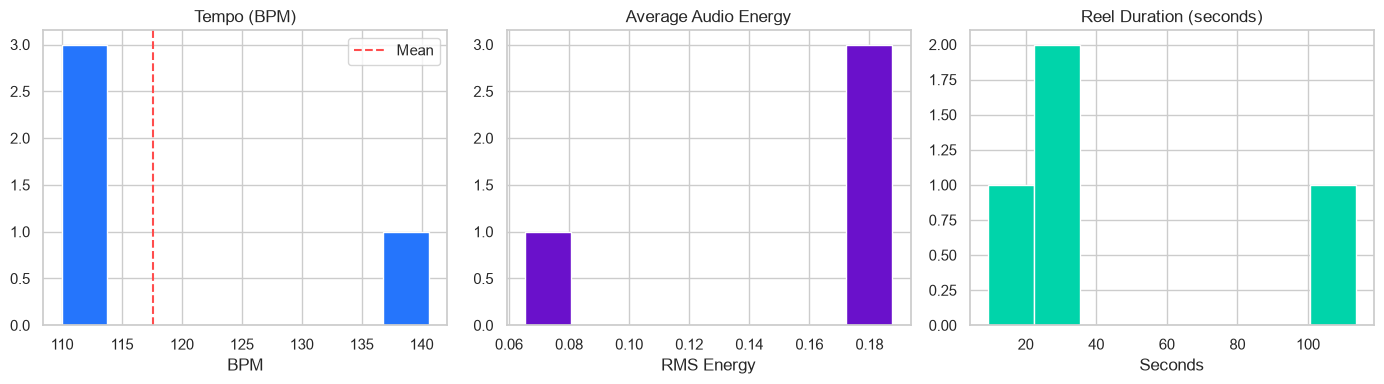

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(audio_df["tempo_bpm"], bins=8, color="#2575fc", edgecolor="white")
axes[0].axvline(audio_df["tempo_bpm"].mean(), color="#ff4d4d", linestyle="--", label="Mean")
axes[0].set_title("Tempo (BPM)")
axes[0].set_xlabel("BPM")
axes[0].legend()

axes[1].hist(audio_df["avg_energy"], bins=8, color="#6a11cb", edgecolor="white")
axes[1].set_title("Average Audio Energy")
axes[1].set_xlabel("RMS Energy")

axes[2].hist(audio_df["duration_sec"], bins=8, color="#00d4aa", edgecolor="white")
axes[2].set_title("Reel Duration (seconds)")
axes[2].set_xlabel("Seconds")

plt.tight_layout()
plt.show()

## 3. Beat-Sync Slide Duration Analysis

In [5]:
def parse_slide_durations(value: str) -> list[float]:
    return [float(part) for part in str(value).split("|") if part]

audio_df["slide_list"] = audio_df["slide_durations"].apply(parse_slide_durations)
audio_df["slide_std"] = audio_df["slide_list"].apply(np.std)
audio_df["slide_min"] = audio_df["slide_list"].apply(np.min)
audio_df["slide_max"] = audio_df["slide_list"].apply(np.max)

audio_df[["reel_id", "image_count", "avg_slide_duration", "slide_std", "slide_min", "slide_max"]].head()

,reel_id,image_count,avg_slide_duration,slide_std,slide_min,slide_max
0,6f542634-7b74-11f1-8cf5-04ecd80f8fe4,10,11.350,1.776357e-15,11.350,11.350
1,f08c2cc6-7b77-11f1-b783-04ecd80f8fe4,7,3.589,5.120884e-01,2.694,4.419
2,66432ef0-7b7a-11f1-afa6-04ecd80f8fe4,9,2.791,4.235482e-01,2.148,3.874
3,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,7,1.341,4.330865e-01,0.917,2.323


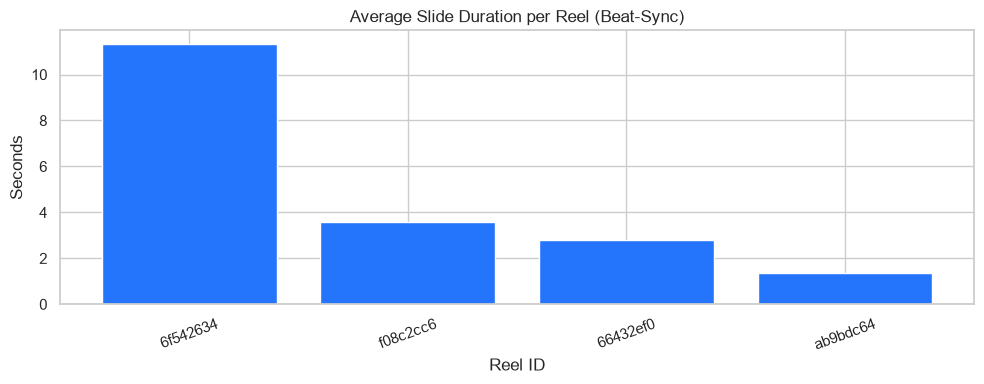

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    audio_df["reel_id"].str[:8],
    audio_df["avg_slide_duration"],
    color="#2575fc",
    edgecolor="white",
)
ax.set_title("Average Slide Duration per Reel (Beat-Sync)")
ax.set_xlabel("Reel ID")
ax.set_ylabel("Seconds")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Correlation Between Audio Features

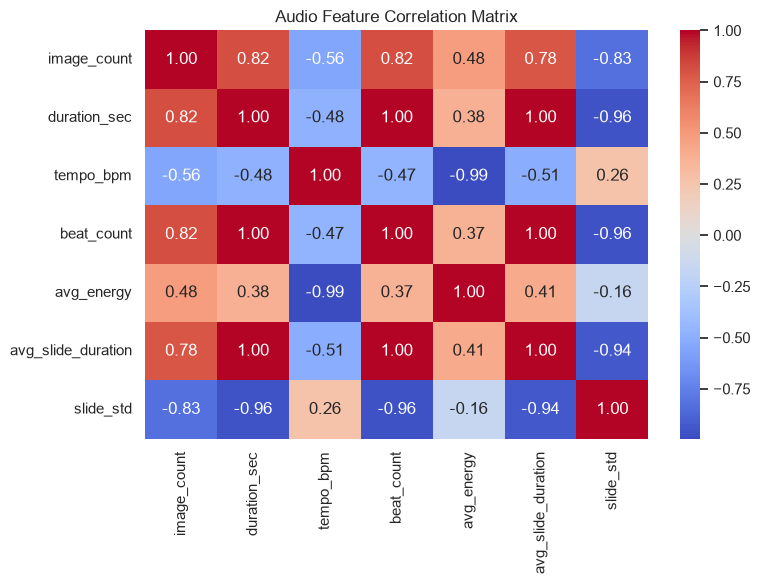

In [7]:
numeric_cols = [
    "image_count", "duration_sec", "tempo_bpm",
    "beat_count", "avg_energy", "avg_slide_duration", "slide_std",
]
corr = audio_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Audio Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 5. Key Findings

- **Tempo (BPM)** is detected using librosa beat tracking on each reel's audio.
- **Beat-sync** assigns variable slide durations instead of a fixed 1-second interval.
- Higher `slide_std` indicates more dynamic timing aligned to music beats.
- These features form the audio signal processing pillar of the DReel AI pipeline.